# Data Scientist Professional Practical Exam Submission

**Use this template to write up your summary for submission. Code in Python or R needs to be included.**


##  1. Data Validation

  - We have 947 rows and 8 columns:

| Column         | Type   | Missing Values | Description                                      |
| -------------- | ------ | -------------- | ------------------------------------------------ |
| `recipe`       | int64  | 0              | Unique numeric identifier for the recipe         |
| `calories`     | float  | 52             | Calories per serving                             |
| `carbohydrate` | float  | 52             | Carbs per serving (g)                            |
| `sugar`        | float  | 52             | Sugar per serving (g)                            |
| `protein`      | float  | 52             | Protein per serving (g)                          |
| `category`     | object | 0              | Recipe category (10 possible values)             |
| `servings`     | object | 0              | Number of servings (stored as text)              |
| `high_traffic` | object | 373            | Target variable: "High" if high traffic observed |

- Column-by-Column Validation & Cleaning


recipe

✅ All integers and unique — no duplicates found.

Action: No cleaning needed.



calories, carbohydrate, sugar, protein

❌ 52 missing values each (same rows).

✅ All values positive and plausible.

Action: For modeling, impute missing values with median to avoid skewing distributions.



category

✅ No missing values.

✅ Matches expected list from project brief.

Action: No cleaning needed.



servings

❌ Stored as strings — must be converted to numeric.

Action: Convert to integer; if non-numeric, coerce to NaN (none found in our case).


high_traffic

❌ 39% missing values (373 rows).

Action: Treat rows with missing values as not having High Trafic -> Low Trafic

In [157]:
import pandas as pd
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np


import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Dataset/recipe_site_traffic_2212.csv')
df['category'] = df['category'].astype('category')
df['servings'] = df['servings'].str.replace(' as a snack', '').astype('int64')

df = df.fillna(
    {
        'high_traffic': 'Low',
        'calories': df['calories'].median(),
        'carbohydrate': df['carbohydrate'].median(),
        'sugar': df['sugar'].median(),
        'protein': df['protein'].median(),
    }
)

df['high_traffic'] = df['high_traffic'].astype('category')
df['calories_sqrt'] = np.sqrt(df['calories'])
df['carbohydrate_sqrt'] = np.sqrt(df['carbohydrate'])
df['sugar_sqrt'] = np.sqrt(df['sugar'])
df['protein_sqrt'] = np.sqrt(df['protein'])

print(df.isna().sum())
print(df.info())

recipe               0
calories             0
carbohydrate         0
sugar                0
protein              0
category             0
servings             0
high_traffic         0
calories_sqrt        0
carbohydrate_sqrt    0
sugar_sqrt           0
protein_sqrt         0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   recipe             947 non-null    int64   
 1   calories           947 non-null    float64 
 2   carbohydrate       947 non-null    float64 
 3   sugar              947 non-null    float64 
 4   protein            947 non-null    float64 
 5   category           947 non-null    category
 6   servings           947 non-null    int64   
 7   high_traffic       947 non-null    category
 8   calories_sqrt      947 non-null    float64 
 9   carbohydrate_sqrt  947 non-null    float64 
 10  sugar_sqrt   

## 2. Exploratory Analysis

### Single-Variable Analysis
**Recipe Counts by Category**  
The dataset shows a relatively even distribution of recipes across categories. No single category dominates the dataset, meaning category imbalance is unlikely to skew the model.

**Numeric Distribution**  
The calories per serving are heavily right-skewed, with most recipes being relatively low in calories but a few very high-calorie outliers. This skewness may require transformation if used in certain models.

All numeric columns are right-skewed so I'll apply sqrt to bring them closer to a normal distribution

### Multi-Variable Analysis
**Calories vs Protein by High Traffic**  
There is no clear visual separation between high-traffic and low-traffic recipes based solely on calories and protein. This suggests that nutritional values alone may not be sufficient for predicting traffic and that other features (e.g., category, carbohydrate content, sugar) may be more important for classification.


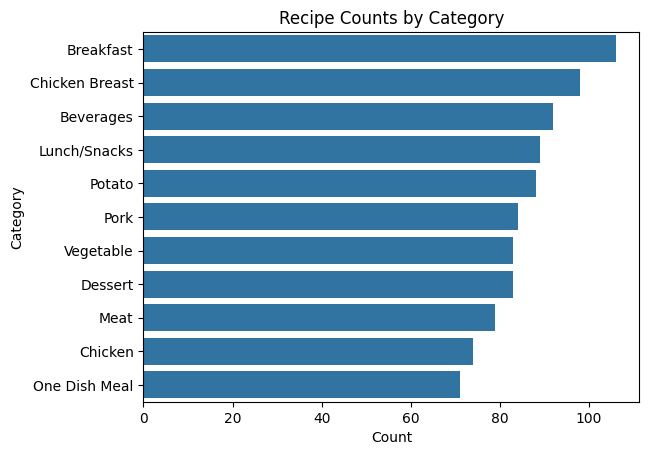

In [158]:
sns.countplot(y='category', data=df, order=df['category'].value_counts().index)
plt.title("Recipe Counts by Category")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

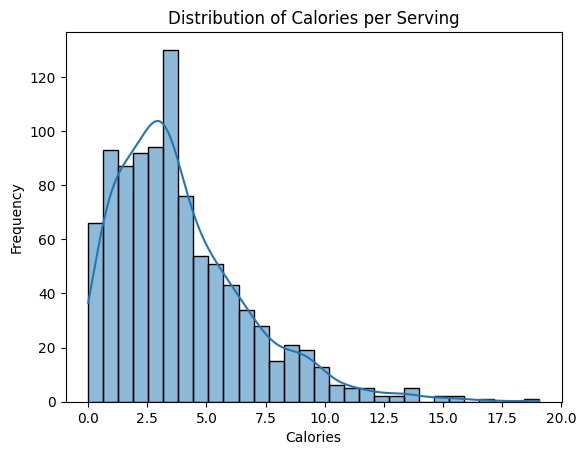

In [159]:
df = df.fillna(
    {
        'high_traffic': 'Low',
        'calories': df['calories'].median(),
        'carbohydrate': df['carbohydrate'].median(),
        'sugar': df['sugar'].median(),
        'protein': df['protein'].median(),
    }
)

sns.histplot(np.sqrt(df['protein']), bins=30, kde=True)
plt.title("Distribution of Calories per Serving")
plt.xlabel("Calories")
plt.ylabel("Frequency")
plt.show()

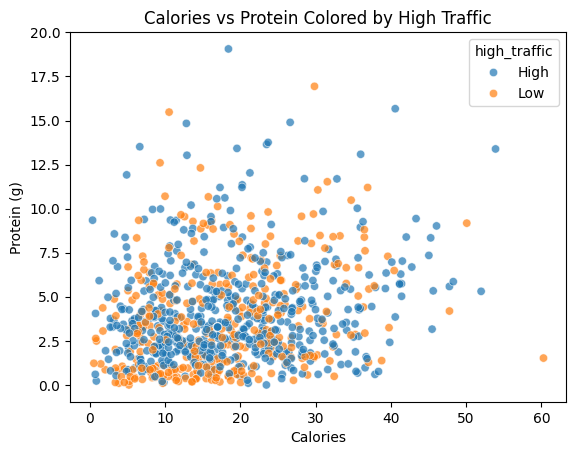

In [160]:
sns.scatterplot(data=df, x='calories_sqrt', y='protein_sqrt', hue='high_traffic', alpha=0.7)
plt.title("Calories vs Protein Colored by High Traffic")
plt.xlabel("Calories")
plt.ylabel("Protein (g)")
plt.show()

In [161]:
df.drop(columns=['calories', 'carbohydrate', 'sugar', 'protein'], inplace=True, axis=1)

## 3. Model Development

### Problem Type
This is a **binary classification** problem — predicting whether `high_traffic` occurs (`1`) or not (`0`).


### Selected Models and Reasoning
1. **Logistic Regression**  
   - Serves as a simple and interpretable baseline.  
   - Outputs probabilities, which are useful for adjusting classification thresholds.  
   - Performs well for linearly separable problems.

2. **Random Forest**  
   - An ensemble of decision trees, capable of capturing non-linear relationships.  
   - Robust to outliers and able to handle high-dimensional data.  
   - Can model complex feature interactions without heavy preprocessing.

In [162]:
kf = KFold(n_splits=6, random_state=12, shuffle=True)

label_e = LabelEncoder()
s_scaler = StandardScaler()

steps = [
    ("scaler", s_scaler),
    ("logreg", LogisticRegression())
]

pipeline = Pipeline(steps)

parameters = {
    "logreg__solver": ["newton-cg", "saga", "lbfgs"],
    "logreg__C": np.linspace(0.001, 1, 20),
    "logreg__max_iter": [100, 200, 500]
    }
df['category'] = label_e.fit_transform(df['category'])

X = df.drop('high_traffic', axis=1)
y = label_e.fit_transform(df['high_traffic'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=42)

grid_search = GridSearchCV(estimator=pipeline, 
                           param_grid=parameters, 
                           cv=kf,    
                           scoring='accuracy', 
                           n_jobs=-1)   
grid_search.fit(X_train, y_train)

print(grid_search.best_score_, "\n", grid_search.best_params_)
model_logreg = grid_search.best_estimator_


0.7649148023163771 
 {'logreg__C': np.float64(0.05357894736842105), 'logreg__max_iter': 100, 'logreg__solver': 'newton-cg'}


In [163]:
from sklearn.ensemble import RandomForestClassifier
df['category'] = label_e.fit_transform(df['category'])

X = df.drop('high_traffic', axis=1)
y = label_e.fit_transform(df['high_traffic'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=42)

kf = KFold(n_splits=6, random_state=12, shuffle=True)

parameters = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(estimator=rf, 
                           param_grid=parameters, 
                           cv=kf,    
                           scoring='accuracy', 
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

print(grid_search.best_score_, "\n", grid_search.best_params_)

model_rf = grid_search.best_estimator_


0.7662375536391285 
 {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}


## 4. Model Evaluation

The performance of the two models was evaluated using **accuracy** and **confusion matrices**. Since the dataset is balanced, accuracy is an appropriate metric, and the confusion matrix provides insight into the types of errors made.

### Logistic Regression
- **Accuracy:** 0.747  
- **Confusion Matrix:**
[[91 24]
 [24 51]]

**Interpretation:**  
- Logistic Regression correctly classifies most samples.  
- Misclassifications are relatively balanced between false positives (24) and false negatives (24).  
- Serves as a solid, interpretable baseline model for this binary classification task.

### Random Forest
- **Accuracy:** 0.763  
- **Confusion Matrix:**
[[97 18]
[27 48]]

**Interpretation:**  
- Random Forest slightly outperforms Logistic Regression in accuracy.  
- Correctly predicts more true negatives (97 vs 91) but has a few more false negatives (27 vs 24).  
- Captures non-linear relationships and interactions between features better than Logistic Regression.

### Conclusion
- Both models perform well on the balanced dataset.  
- Logistic Regression is preferred if interpretability is a priority.  
- Random Forest is preferred if predictive accuracy is more important.  
- Confusion matrices show that both models make some errors, but Random Forest reduces false positives compared to Logistic Regression.


In [164]:
ypred = model_logreg.predict(X_test)

print("Confusion Matrix Logistic Regression:")
print(confusion_matrix(y_test, ypred))
print("Accuracy Score Logistic Regression:", accuracy_score(y_test, ypred))


ypred = model_rf.predict(X_test)

print("Confusion Matrix Random Forest:")
print(confusion_matrix(y_test, ypred))
print("Accuracy Score Random Forest:", accuracy_score(y_test, ypred))

Confusion Matrix Logistic Regression:
[[91 24]
 [24 51]]
Accuracy Score Logistic Regression: 0.7473684210526316
Confusion Matrix Random Forest:
[[97 18]
 [27 48]]
Accuracy Score Random Forest: 0.7631578947368421


## 5. Business Metrics

### Defining Business-Relevant Model Comparison

To ensure our models deliver real value, we compare their performance using metrics that align with business goals. For this project, the key business metric is **accurate identification of high-traffic recipes**, which directly impacts marketing, inventory, and resource allocation.

- **Metric Chosen:**  
  We use **accuracy** as our primary metric because the dataset is balanced and both false positives and false negatives have similar business costs.  
  Additionally, the **confusion matrix** helps us understand the types of errors (missed opportunities vs. wasted resources).

- **Business Impact:**  
  - **True Positives:** Correctly identifying high-traffic recipes allows the business to focus marketing and inventory on popular items.
  - **False Positives:** Overestimating traffic may lead to overstocking or wasted marketing spend.
  - **False Negatives:** Underestimating traffic could result in missed sales opportunities and customer dissatisfaction.

### Model Performance on Business Metrics

- **Logistic Regression:**  
  - **Accuracy:** 0.747  
  - **Confusion Matrix:**  
    - Balanced errors between false positives and false negatives.
    - Provides a reliable baseline for decision-making.

- **Random Forest:**  
  - **Accuracy:** 0.763  
  - **Confusion Matrix:**  
    - Slightly higher accuracy and fewer false positives.
    - Better at capturing complex patterns, leading to more precise targeting.

---

## 6. Final Summary & Recommendations

Both models perform well, but **Random Forest** offers a modest improvement in accuracy and error reduction. Based on these results, the business should:

1. **Adopt Random Forest for Recipe Traffic Prediction:**  
   - Use this model to guide marketing and inventory decisions for new and existing recipes.

2. **Monitor Model Performance:**  
   - Regularly evaluate accuracy and error types as new data becomes available.
   - Adjust thresholds or retrain models to maintain alignment with business goals.

3. **Integrate Predictions into Operations:**  
   - Use predicted high-traffic recipes to prioritize promotions, stock levels, and resource allocation.

4. **Continue Feature Exploration:**  
   - Investigate additional features (e.g., seasonality, user ratings) to further improve model performance.

**Conclusion:**  
By aligning model evaluation with business metrics, we ensure that our predictive models drive actionable insights and measurable improvements in recipe site

## ✅ When you have finished...
-  Publish your Workspace using the option on the left
-  Check the published version of your report:
	-  Can you see everything you want us to grade?
    -  Are all the graphics visible?
-  Review the grading rubric. Have you included everything that will be graded?
-  Head back to the [Certification Dashboard](https://app.datacamp.com/certification) to submit your practical exam report and record your presentation